# Import packages and libraries

In [21]:

# Package imports
import pandas as pd
import numpy as np
import geopandas as gpd
from pathlib import Path
import os

# For grid cell creation
from shapely.geometry import Polygon

# Setup Directories

In [22]:
CURRENT_DIRECTORY = Path(os.getcwd())
BASE_DATASET_PATH = Path(CURRENT_DIRECTORY).parents[1] / "AED-OHCA" /"datasets"

display(CURRENT_DIRECTORY)
display(BASE_DATASET_PATH   )

PosixPath('/Users/axlee/Desktop/Singhealth/AED-OHCA/dr_sean_code')

PosixPath('/Users/axlee/Desktop/Singhealth/AED-OHCA/datasets')

# Load the Point-Level GeoPackage

In [23]:
ohca_filepath = BASE_DATASET_PATH/"3_OHCA_with_geometric_pts.gpkg"
gdf_ohca = gpd.read_file(ohca_filepath)

display(gdf_ohca.head())

,Case #,Site #,Date of Incident,Location of incident,Location Unknown,Location Type,Location Type Other,Time call received at dispatch center,Estimated time of arrest,lat,lon,geometry
0,SGSIN0213,2,2010-04-01,470146.0,NaN,Home Residence,HDB Level 7,23:29:17,23:35:00,1.334604,103.911889,POINT (36744.065 35199.375)
1,SGSIN0218,2,2010-04-01,520926.0,NaN,Home Residence,HDB Level 2,14:18:54,14:05:00,1.346122,103.940989,POINT (39982.538 36473.112)
2,SGSIN6480,6,2010-04-01,560565.0,NaN,Healthcare Facility,NKF Dialysis Centre,16:35:03,16:30:00,1.369882,103.858475,POINT (30799.605 39100.122)
3,SGSIN5332,5,2010-04-02,680626.0,NaN,Home Residence,HDB Level 7,02:28:08,02:00:00,1.398315,103.745837,POINT (18264.472 42244.265)
4,SGSIN0214,2,2010-04-03,468963.0,NaN,Place of Recreation,East Coast Park NSC Carpark,08:56:21,09:00:00,1.315317,103.961890,POINT (42308.771 33066.957)


# Standardize Time and Filter from 2019 to 2021

Replace 'INC_CREATE_TIME' with PAROS 'Date of Incident'

In [24]:
gdf_ohca['Date of Incident'] = pd.to_datetime(gdf_ohca['Date of Incident'],
                                              format='mixed')
df_2019_to_2021 = gdf_ohca[gdf_ohca['Date of Incident'].dt.year.between(2019, 2021)].copy()
display(df_2019_to_2021.head())

,Case #,Site #,Date of Incident,Location of incident,Location Unknown,Location Type,Location Type Other,Time call received at dispatch center,Estimated time of arrest,lat,lon,geometry
17665,SGSIN01135791,1,2019-01-01,670516.0,NaN,Home Residence,NaN,09:30:41,09:30:00,1.387268,103.767236,POINT (20645.861 41022.665)
17666,SGSIN01135792,1,2019-01-01,670253.0,NaN,Home Residence,NaN,20:13:32,20:00:00,1.379610,103.774588,POINT (21464.023 40175.861)
17667,SGSIN01135793,1,2019-01-01,680668.0,NaN,Home Residence,NaN,23:41:32,23:40:00,1.401803,103.749333,POINT (18653.533 42629.937)
17668,SGSIN02136384,2,2019-01-01,416823.0,NaN,In EMS/Private ambulance,NaN,15:46:02,16:23:00,1.320074,103.911580,POINT (36709.728 33592.73)
17669,SGSIN04136999,4,2019-01-01,735689.0,NaN,Home Residence,NaN,16:10:16,16:05:00,1.443868,103.808552,POINT (25243.867 47281.12)


# CRS Verification

Ensure that the pointas are in SVY21 (EPSG:3414) for accurate hectare grid calculation

In [25]:
if df_2019_to_2021.crs != "EPSG:3414":
    df_2019_to_2021 = df_2019_to_2021.to_crs(epsg=3414)

print(f"Successfully loaded {len(df_2019_to_2021)} OHCA points for the 2019-2021 simulation grid.")
display(df_2019_to_2021[['Case #', 'Date of Incident', 'geometry']].head())

Successfully loaded 9962 OHCA points for the 2019-2021 simulation grid.


,Case #,Date of Incident,geometry
17665,SGSIN01135791,2019-01-01,POINT (20645.861 41022.665)
17666,SGSIN01135792,2019-01-01,POINT (21464.023 40175.861)
17667,SGSIN01135793,2019-01-01,POINT (18653.533 42629.937)
17668,SGSIN02136384,2019-01-01,POINT (36709.728 33592.73)
17669,SGSIN04136999,2019-01-01,POINT (25243.867 47281.12)


# Define extent (bounding box) of the grid

Take the minimum and maximum coordinates of the 2019-2021 OHCA points

In [26]:
xmin, ymin, xmax, ymax = df_2019_to_2021.total_bounds
display(xmin, ymin, xmax, ymax)

np.float64(3616.5933423814167)

np.float64(25121.36140110203)

np.float64(46782.8845840514)

np.float64(49925.082729268266)

# Create a grid of 30 x 20 and calculate the width and height of each individual grid cell

In [27]:
n_cols = 30
n_rows = 20

cell_width = (xmax - xmin) / n_cols
cell_height = (ymax - ymin) / n_rows

display(cell_width, cell_height)

np.float64(1438.8763747223327)

np.float64(1240.186066408312)

# Creating the Grid Geometry

Since NetLogo coordinates usually start from bottom-left, will need o calculate the actual map coordinates for the specific cell before creating a polygon square

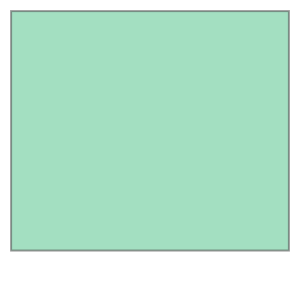

In [35]:
grid_cells = []

for y_idx in range(n_rows):
    for x_idx in range(n_cols):
        x0 = xmin + x_idx * cell_width
        y0 = ymin + y_idx * cell_height
        x1 = x0 + cell_width
        y1 = y0 + cell_height

        grid_cells.append(Polygon([(x0, y0), (x1, y0), (x1, y1), (x0, y1)]))

display(grid_cells[0])

# Convert to GeoDataFram and assign NetLogo patch coordinates

Creating pxcor and pycor -> Defines a patch's fixed location where pxcor increases to the right and pycor increases upwards

In [30]:
grids_gdf = gpd.GeoDataFrame(geometry=grid_cells,
                            crs="EPSG:3414")
grids_gdf['pxcor'] = np.tile(np.arange(n_cols), n_rows)
grids_gdf['pycor'] = np.repeat(np.arange(n_rows), n_cols)

display(grids_gdf['pxcor'])
display(grids_gdf['pycor'])

0       0
1       1
2       2
3       3
4       4
       ..
595    25
596    26
597    27
598    28
599    29
Name: pxcor, Length: 600, dtype: int64

0       0
1       0
2       0
3       0
4       0
       ..
595    19
596    19
597    19
598    19
599    19
Name: pycor, Length: 600, dtype: int64

# Perform spatial join

To map every OHCA poin to the grid cell it falls inside

In [31]:
merged_df = gpd.sjoin(df_2019_to_2021,
                      grids_gdf,
                      how='inner',
                      predicate='within')

display(merged_df.head())

,Case #,Site #,Date of Incident,Location of incident,Location Unknown,Location Type,Location Type Other,Time call received at dispatch center,Estimated time of arrest,lat,lon,geometry,index_right,pxcor,pycor
17665,SGSIN01135791,1,2019-01-01,670516.0,NaN,Home Residence,NaN,09:30:41,09:30:00,1.387268,103.767236,POINT (20645.861 41022.665),371,11,12
17666,SGSIN01135792,1,2019-01-01,670253.0,NaN,Home Residence,NaN,20:13:32,20:00:00,1.379610,103.774588,POINT (21464.023 40175.861),372,12,12
17667,SGSIN01135793,1,2019-01-01,680668.0,NaN,Home Residence,NaN,23:41:32,23:40:00,1.401803,103.749333,POINT (18653.533 42629.937),430,10,14
17668,SGSIN02136384,2,2019-01-01,416823.0,NaN,In EMS/Private ambulance,NaN,15:46:02,16:23:00,1.320074,103.911580,POINT (36709.728 33592.73),202,22,6
17669,SGSIN04136999,4,2019-01-01,735689.0,NaN,Home Residence,NaN,16:10:16,16:05:00,1.443868,103.808552,POINT (25243.867 47281.12),525,15,17


# Checking counts of incidents per cell

In [34]:
grid_counts = merged_df.groupby(['pxcor', 'pycor']).size().reset_index(name='incident_count')
display(grid_counts.head())

,pxcor,pycor,incident_count
0,0,4,7
1,0,6,3
2,1,2,2
3,1,3,1
4,1,4,2


# Merging the counts back onto the master grid

In [37]:
final_grid = grids_gdf.merge(grid_counts,
                             on=['pxcor','pycor'],
                             how='left')
final_grid['incident_count'] = final_grid['incident_count'].fillna(0)

print(f"Total raw incidents from 2019 - 2021: {final_grid['incident_count'].sum()}")

Total raw incidents from 2019 - 2021: 9961.0


# Calculate 3 Year Annual Average

In [38]:
final_grid['incident_count'] = final_grid['incident_count'] / 3.0

print(f"Generated a {n_cols}x{n_rows} grid ({len(final_grid)} total patches).")
print(f"Average annual OHCA incidents mapped into the grid: {final_grid['incident_count'].sum()}")

Generated a 30x20 grid (600 total patches).
Average annual OHCA incidents mapped into the grid: 3320.333333333333


# Export for NetLogo

In [39]:
export_path = BASE_DATASET_PATH / "singapore_data/cleaned_data/ohca_data/grid_2019_2021_avg_counts_for_netlogo.csv"

final_grid[['pxcor', 'pycor', 'incident_count']].to_csv(export_path, index=False)
print(f"Ready for simulation! Exported to: {export_path}")

Ready for simulation! Exported to: /Users/axlee/Desktop/Singhealth/AED-OHCA/datasets/singapore_data/cleaned_data/ohca_data/grid_2019_2021_avg_counts_for_netlogo.csv
